# Projekt 2 - Regresia a klasifikácia dát `[20b]`

Budeme pracovať s datasetom údajov o počasí v Bratislave. Dataset obsahuje hodinové záznamy s meraniami rôznych príznakov (teplota, vlhkosť vzduchu, zrážky a pod.). Cieľom projektu je:
* 1.časť - predpovedať teplotu (stĺpec `temp`) pre daný hodinový záznam pomocou jednoduchej alebo viacnásobnej regresie
* 2.časť - klasifikovať kód počasia pre daný hodinový záznam pomocou rôznych klasifikačných modelov.

**Úlohy:**

1. Import
2. Čistenie a transformácia `[2b]`
3. Exploračná analýza `[1b]`
4. Rozdelenie datasetu na trénovaciu/testovaciu množinu `0.5b`
5. Normalizácia `[0.5b]`
6. Regresia `[8b]`
    1. Jednoduchá regresia (lineárna alebo polynomiálna) `[4b]`
    2. Viacnásobná regresia (lineárna alebo polynomiálna) `[4b]`
7. Klasifikácia `[8b]`
    1. Single klasifikátor (Logistic Regression, K-Nearest Neighbours, Decision Tree) `[4b]`
    2. Ensemble klasifikátor (Random Forest, XGBoost, Basic Stacking) `[4b]`

In [35]:
#!pip install meteostat

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sb
from datetime import date
import meteostat as ms
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost
from yellowbrick.classifier import ROCAUC

## 1. Import

Pomocou knižnice `meteostat` načítajte hodinové dáta o počasí pre Bratislavu za obdobie 1.1.2022 - 31.12.2025. Meteostanica v Bratislave ma číselný kód 11816. Na načítanie použite dodanú funkciu `load_weather_data()`.

Dataset obsahuje tieto stĺpce:

- `temp` - teplota vzduchu v °C
- `rhum` - relatívna vlhkosť vzduchu v %
- `prcp` - celkový úhrn zrážok v mm
- `snwd` - výška snehovej pokrývky v mm
- `wdir` - smer vetra v stupňoch (0° – 360°)
- `wspd` - rýchlosť vetra v km/h
- `wpgt` - maximálny náraz vetra v km/h
- `pres` - tlak vzduchu v hPa
- `tsun` - počet minút slnečného svitu počas danej hodiny
- `cldc` - oblačnosť vyjadrená v rozsahu 0–8
- `coco` - [Kód počasia](https://dev.meteostat.net/formats#weather-condition-codes) pre danú hodinu

**Kódy počasia:**

* `1`	Clear
* `2`	Fair
* `3`	Cloudy
* `4`	Overcast
* `5`	Fog
* `6`	Freezing Fog
* `7`	Light Rain
* `8`	Rain
* `9`	Heavy Rain
* `10`	Freezing Rain
* `11`	Heavy Freezing Rain
* `12`	Sleet
* `13`	Heavy Sleet
* `14`	Light Snowfall
* `15`	Snowfall
* `16`	Heavy Snowfall
* `17`	Rain Shower
* `18`	Heavy Rain Shower
* `19`	Sleet Shower
* `20`	Heavy Sleet Shower
* `21`	Snow Shower
* `22`	Heavy Snow Shower
* `23`	Lightning
* `24`	Hail
* `25`	Thunderstorm
* `26`	Heavy Thunderstorm
* `27`	Storm

In [37]:
# funkcia na ziskanie hodinovych udajov o pocasi pre meteostanicu a casove obdobie
# funkcia vrati DataFrame, kde kazdy riadok predstavuje 1 hodinu
# ciselny kod pre meteostanicu v Bratislave je 11816
def load_weather_data(start_date: date, end_date: date, station_id: int):
    # ziskanie meteostanice
    station = ms.Station(id=str(station_id))

    # ziskanie DataFrame-u s pocasim pre stanicu a obdobie
    ts = ms.hourly(station, start_date, end_date)
    df = ts.fetch()
    return df

**U1:** Pomocou funkcie `load_weather_data()` načítajte dataset.

In [38]:
# Nacitanie datasetu pomocou dodanej funkcie
df = load_weather_data(date(2022,1,1), date(2025,12,31), 11816)

**U2:** Zobrazte náhľad datasetu.

In [39]:
# Nahlad datasetu
df

,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
time,,,,,,,,,,,
2022-01-01 00:00:00,13.7,67,<NA>,<NA>,280,28.8,24.1,1019.4,<NA>,7,4
2022-01-01 01:00:00,13.7,66,<NA>,<NA>,290,36.0,25.9,1019.8,<NA>,4,2
2022-01-01 02:00:00,13.4,65,<NA>,<NA>,280,25.2,31.5,1020.9,<NA>,5,2
2022-01-01 03:00:00,13.3,67,<NA>,<NA>,0,7.2,35.2,1021.6,<NA>,6,3
2022-01-01 04:00:00,12.9,68,<NA>,<NA>,200,7.6,33.3,1022.2,<NA>,6,3
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,0.0,75,0.2,<NA>,270,28.0,31.5,1014.0,0,2,14
2025-12-31 20:00:00,0.0,75,0.2,<NA>,270,24.0,33.3,1014.0,0,8,14
2025-12-31 21:00:00,0.6,73,0.0,<NA>,270,32.0,35.2,1015.3,0,8,12


## 2. Čistenie a transformácia `[2b]`

**U1:** Koľko dát chýba v jednotlivých stĺpcoch?

In [40]:
# Zobrazenie percentualnej pocetnosti chybajucich dat v kazdom stlpci
(df.isna().mean()*100).reset_index()

,index,0
0,temp,0.000000
1,rhum,0.000000
2,prcp,10.004563
3,snwd,99.771846
4,wdir,0.000000
5,wspd,0.000000
6,wpgt,0.750057
7,pres,0.000000
8,tsun,24.720511
9,cldc,1.631303


**U2:** Vymažte celé stĺpce, kde chýba viac ako 50 % dát.

In [41]:
# zmazanie stlpca "snwd", lebo iba tam chyba viac ako 50% dat, skoro az 100%
del(df["snwd"])
df

,temp,rhum,prcp,wdir,wspd,wpgt,pres,tsun,cldc,coco
time,,,,,,,,,,
2022-01-01 00:00:00,13.7,67,<NA>,280,28.8,24.1,1019.4,<NA>,7,4
2022-01-01 01:00:00,13.7,66,<NA>,290,36.0,25.9,1019.8,<NA>,4,2
2022-01-01 02:00:00,13.4,65,<NA>,280,25.2,31.5,1020.9,<NA>,5,2
2022-01-01 03:00:00,13.3,67,<NA>,0,7.2,35.2,1021.6,<NA>,6,3
2022-01-01 04:00:00,12.9,68,<NA>,200,7.6,33.3,1022.2,<NA>,6,3
...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,0.0,75,0.2,270,28.0,31.5,1014.0,0,2,14
2025-12-31 20:00:00,0.0,75,0.2,270,24.0,33.3,1014.0,0,8,14
2025-12-31 21:00:00,0.6,73,0.0,270,32.0,35.2,1015.3,0,8,12


**U3:** Vymažte všetky riadky, kde chýbajú hodnoty (v hociktorom stĺpci). Výsledkom bude dataset, kde bude v každom stĺpci 0 % chýbajúcich dát.

In [42]:
# Vymazanie riadkov kde chyba aspon 1 hodnota v lubovolnom stlpci
df = df.dropna()
(df.isna().mean()*100).reset_index()

,index,0
0,temp,0.0
1,rhum,0.0
2,prcp,0.0
3,wdir,0.0
4,wspd,0.0
5,wpgt,0.0
6,pres,0.0
7,tsun,0.0
8,cldc,0.0
9,coco,0.0


**U4:** Dataset používa dátum ako index. Spravte z dátumu klasický stĺpec a nastavte datasetu nový numerický index číslovaný od 0.

In [43]:
# vytvorenie numerickeho indexovania, zo stlpca time sa stava klasicky stlpec
df = df.reset_index()
df

,time,temp,rhum,prcp,wdir,wspd,wpgt,pres,tsun,cldc,coco
0,2022-08-09 16:00:00,28.2,33,0.0,330,28.8,35.2,1020.5,47,2,2
1,2022-08-09 17:00:00,26.9,34,0.0,340,28.8,31.5,1020.6,42,1,2
2,2022-08-09 18:00:00,25.4,36,0.0,340,21.6,27.8,1021.3,28,1,1
3,2022-08-09 19:00:00,23.6,38,0.0,340,14.4,25.9,1022.2,7,1,2
4,2022-08-10 04:00:00,16.8,67,0.0,359,3.6,13.0,1024.0,3,5,3
...,...,...,...,...,...,...,...,...,...,...,...
26364,2025-12-31 19:00:00,0.0,75,0.2,270,28.0,31.5,1014.0,0,2,14
26365,2025-12-31 20:00:00,0.0,75,0.2,270,24.0,33.3,1014.0,0,8,14
26366,2025-12-31 21:00:00,0.6,73,0.0,270,32.0,35.2,1015.3,0,8,12
26367,2025-12-31 22:00:00,1.0,69,0.2,270,19.0,37.0,1014.0,0,8,14


**U5:** Vytvorte v datasete nový stĺpec s názvom `coco_name`, ktorý bude predstavovať slovné pomenovanie kódu počasia.

In [44]:
# vytvorenie slovnika kde kluc je kod pocasia zo stlpca coco a hodnota kluca je slovny popis kodu pocasia
slovnik = {
    1:"Clear",
    2:"Fair",
    3:"Cloudy",
    4:"Overcast",
    5:"Fog",
    6:"Freezing Fog",
    7:"Light Rain",
    8:"Rain",
    9:"Heavy Rain",
    10:"Freezing Rain",
    11:"Heavy Freezing Rain",
    12:"Sleet",
    13:"Heavy Sleet",
    14:"Light Snowfall",
    15:"Snowfall",
    16:"Heavy Snowfall",
    17:"Rain Shower",
    18:"Heavy Rain Shower",
    19:"Sleet Shower",
    20:"Heavy Sleet Shower",
    21:"Snow Shower",
    22:"Heavy Snow Shower",
    23:"Lightning",
    24:"Hail",
    25:"Thunderstorm",
    26:"Heavy Thunderstorm",
    27:"Storm"
}

# vytvorenie noveho stlpca namapovanim kodu pocasia na slovny popis
df["coco_name"] = df["coco"].map(slovnik)
df

,time,temp,rhum,prcp,wdir,wspd,wpgt,pres,tsun,cldc,coco,coco_name
0,2022-08-09 16:00:00,28.2,33,0.0,330,28.8,35.2,1020.5,47,2,2,Fair
1,2022-08-09 17:00:00,26.9,34,0.0,340,28.8,31.5,1020.6,42,1,2,Fair
2,2022-08-09 18:00:00,25.4,36,0.0,340,21.6,27.8,1021.3,28,1,1,Clear
3,2022-08-09 19:00:00,23.6,38,0.0,340,14.4,25.9,1022.2,7,1,2,Fair
4,2022-08-10 04:00:00,16.8,67,0.0,359,3.6,13.0,1024.0,3,5,3,Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...
26364,2025-12-31 19:00:00,0.0,75,0.2,270,28.0,31.5,1014.0,0,2,14,Light Snowfall
26365,2025-12-31 20:00:00,0.0,75,0.2,270,24.0,33.3,1014.0,0,8,14,Light Snowfall
26366,2025-12-31 21:00:00,0.6,73,0.0,270,32.0,35.2,1015.3,0,8,12,Sleet
26367,2025-12-31 22:00:00,1.0,69,0.2,270,19.0,37.0,1014.0,0,8,14,Light Snowfall


**U6:** Zlučovanie kódov počasia

Podobné kódy počasia zlúčte do jedného spoločného kódu počasia. Podľa nižšie uvedených pravidiel prečíslujte existujúci dataset. Robíme to pre to, aby sme znížili komplexnosť datasetu tým, že spojíme blízke kódy do jedného (napr. `Fog` a `Freezing Fog` spojíme do jedného kódu `Fog`).

Pravidlá zlučovania kódov počasia (vznikne 5 rôznych tried):

* `Clear` (jasno):
    * Clear
    * Fair
* `Cloudy` (oblačno):
    * Cloudy
    * Overcast
* `Fog` (hmla):
    * Fog
    * Freezing Fog
* `Sleet_or_Snowfall` (dážď so snehom/sneženie/snehové prehánky):
    * Sleet
    * Heavy Sleet
    * Sleet Shower
    * Heavy Sleet Shower
    * Freezing Rain
    * Heavy Freezing Rain
    * Light Snowfall
    * Snowfall
    * Heavy Snowfall
    * Snow Shower
    * Heavy Snow Shower
* `Rain_or_Storm` (prehánky/krúpy/dážď/búrka):
    * Light Rain
    * Rain
    * Heavy Rain
    * Rain Shower
    * Heavy Rain Shower
    * Lightning
    * Hail
    * Thunderstorm
    * Heavy Thunderstorm
    * Storm

In [45]:
# slovnik na premapovanie ciselnych kodov na zlucene kody pocasia
slovnik1 = {
    1: 0,
    2: 0,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: 4,
    8: 4,
    9: 4,
    10: 3,
    11: 3,
    12: 3,
    13: 3,
    14: 3,
    15: 3,
    16: 3,
    17: 4,
    18: 4,
    19: 3,
    20: 3,
    21: 3,
    22: 3,
    23: 4,
    24: 4,
    25: 4,
    26: 4,
    27: 4,
}

# premapovanie
df["coco_general"] = df["coco"].map(slovnik1)

# slovnik na premapovanie slovnych nazvov pocasia na zlucene nazvy
slovnik2 = {
    1: "Clear",
    2: "Clear",
    3: "Cloudy",
    4: "Cloudy",
    5: "Fog",
    6: "Fog",
    7: "Rain_or_Storm",
    8: "Rain_or_Storm",
    9: "Rain_or_Storm",
    10: "Sleet_or_Snowfall",
    11: "Sleet_or_Snowfall",
    12: "Sleet_or_Snowfall",
    13: "Sleet_or_Snowfall",
    14: "Sleet_or_Snowfall",
    15: "Sleet_or_Snowfall",
    16: "Sleet_or_Snowfall",
    17: "Rain_or_Storm",
    18: "Rain_or_Storm",
    19: "Sleet_or_Snowfall",
    20: "Sleet_or_Snowfall",
    21: "Sleet_or_Snowfall",
    22: "Sleet_or_Snowfall",
    23: "Rain_or_Storm",
    24: "Rain_or_Storm",
    25: "Rain_or_Storm",
    26: "Rain_or_Storm",
    27: "Rain_or_Storm",
}

# premapovanie
df["coco_general_name"] = df["coco"].map(slovnik2)

**U7:** Zobrazte náhľad datasetu.

In [46]:
# nahlad
df

,time,temp,rhum,prcp,wdir,wspd,wpgt,pres,tsun,cldc,coco,coco_name,coco_general,coco_general_name
0,2022-08-09 16:00:00,28.2,33,0.0,330,28.8,35.2,1020.5,47,2,2,Fair,0,Clear
1,2022-08-09 17:00:00,26.9,34,0.0,340,28.8,31.5,1020.6,42,1,2,Fair,0,Clear
2,2022-08-09 18:00:00,25.4,36,0.0,340,21.6,27.8,1021.3,28,1,1,Clear,0,Clear
3,2022-08-09 19:00:00,23.6,38,0.0,340,14.4,25.9,1022.2,7,1,2,Fair,0,Clear
4,2022-08-10 04:00:00,16.8,67,0.0,359,3.6,13.0,1024.0,3,5,3,Cloudy,1,Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26364,2025-12-31 19:00:00,0.0,75,0.2,270,28.0,31.5,1014.0,0,2,14,Light Snowfall,3,Sleet_or_Snowfall
26365,2025-12-31 20:00:00,0.0,75,0.2,270,24.0,33.3,1014.0,0,8,14,Light Snowfall,3,Sleet_or_Snowfall
26366,2025-12-31 21:00:00,0.6,73,0.0,270,32.0,35.2,1015.3,0,8,12,Sleet,3,Sleet_or_Snowfall
26367,2025-12-31 22:00:00,1.0,69,0.2,270,19.0,37.0,1014.0,0,8,14,Light Snowfall,3,Sleet_or_Snowfall


## 3. Exploračná dátová analýza `[1b]`

Vstupom do exploračnej analýzy budú vyčistené dáta.

**U1:** Vypočítajte a vizualizujte priemernú teplotu v každom mesiaci (berte do úvahy všetky roky). Použite vhodný typ grafu.

<Axes: title={'center': 'Priemerna teplota v kazdom mesiaci'}, xlabel='month', ylabel='temp'>

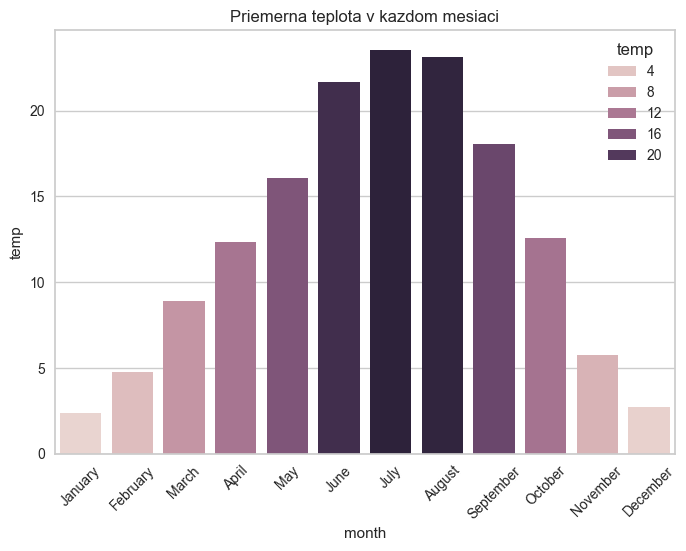

In [47]:
# vyextrahovane mesiaca zo stlpca time a vytvorenie noveho stlpca pre mesiac
df["month"] = df["time"].dt.month

# zgrupenie podla mesiaca a vypocet priemernej teploty v kazdom mesiaci
tmp = df.groupby(by="month")["temp"].mean().reset_index()

# premapovanie ciselnych nazvov mesiacov na slovne
slovnik = {1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June", 7:"July", 8:"August",
          9:"September", 10:"October", 11:"November", 12:"December"}
tmp["month"] = tmp["month"].map(slovnik)

# vizualizacia priemernej teploty v kazdom mesiaci
plt.xticks(rotation=45)
plt.title("Priemerna teplota v kazdom mesiaci")
tmp["temp"] = tmp["temp"].astype("float64") # treba pretypovat, bez toho "hue" hadze error
sb.barplot(data=tmp,x=tmp.month,y=tmp.temp, hue="temp")

**U2:** Zistite, od akého numerického príznaku (stĺpca) najviac závisí teplota - t.j. treba nájsť najvhodnejší prediktor. Vizualizujte danú závislosť vhodným typom grafu (musí byť jasne vidieť silný vzťah medzi obomi príznakmi) a stručne okomentujte výsledok.

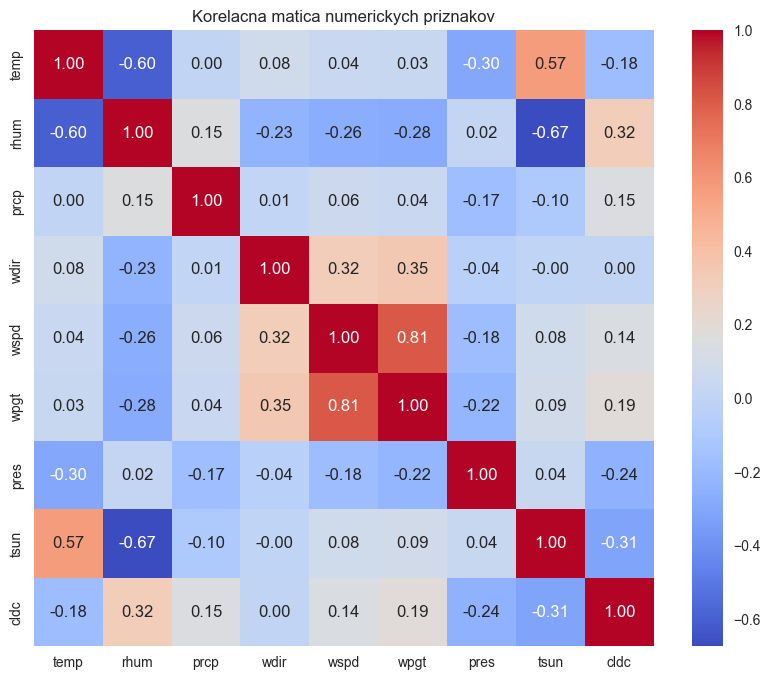

Text(0.5, 1.0, 'Zavislost teploty od relativnej vlhkosti vzduchu v %')

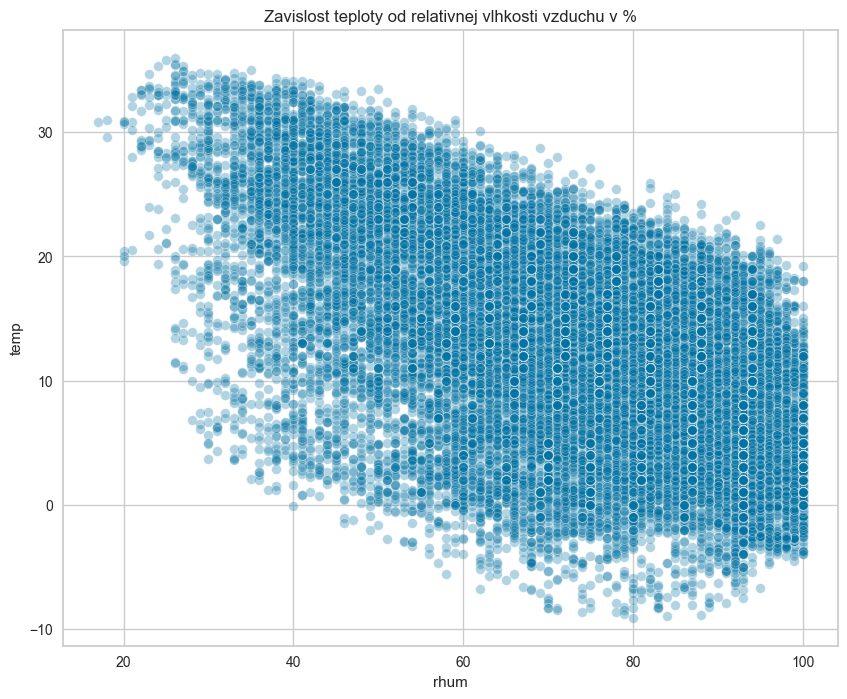

In [48]:
# vizualizacia koleracnej matice na zistenie priznaku, na ktorom najviac zavisi teplota
numeric_cols = df[['temp', 'rhum', 'prcp', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'cldc']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelacna matica numerickych priznakov")
plt.show()

# hladany priznak je "rhum", vizualizacia vztahu cez scatterplot
# cim je vyssia relativna vlhkost vzduchu, tym je aj nizsia teplota
plt.figure(figsize=(10, 8))
sb.scatterplot(data=df, x="rhum", y="temp", alpha=0.3)
plt.title("Zavislost teploty od relativnej vlhkosti vzduchu v %")

**U3:** Nájdite "bláznivé" dni, t.j. také počas ktorých svietilo slnko (stĺpec `tsun`) viac ako 6 hodín a zároveň napršalo (stĺpec `prcp`) viac ako 10 mm zrážok.

In [49]:
# vyrobenie stlpca datum
df["date"] = df["time"].dt.date

# zoskupenie podla datumu a vypocet celkovych statistik za cely den
tmp = df.groupby("date")[["tsun", "prcp"]].sum().reset_index()

# konvercia do hodin
tmp["tsun"] = tmp["tsun"] / 60

# vypisanie len tych pre ktore plati podmienka
crazy_days = tmp[(tmp["tsun"] > 6) & (tmp["prcp"] > 10)]
crazy_days

,date,tsun,prcp
703,2024-07-12,7.783333,15.5
1062,2025-07-06,9.5,13.0
1080,2025-07-24,6.683333,10.4
1089,2025-08-02,6.9,11.1


**U4:** Analyzujte vyváženosť datasetu. Zobrazte vhodný graf s počtom riadkov pre jednotlivé kódy počasia (po zlúčení kódov).

<Axes: title={'center': 'Vyvazenost datasetu'}, xlabel='coco_general_name', ylabel='count'>

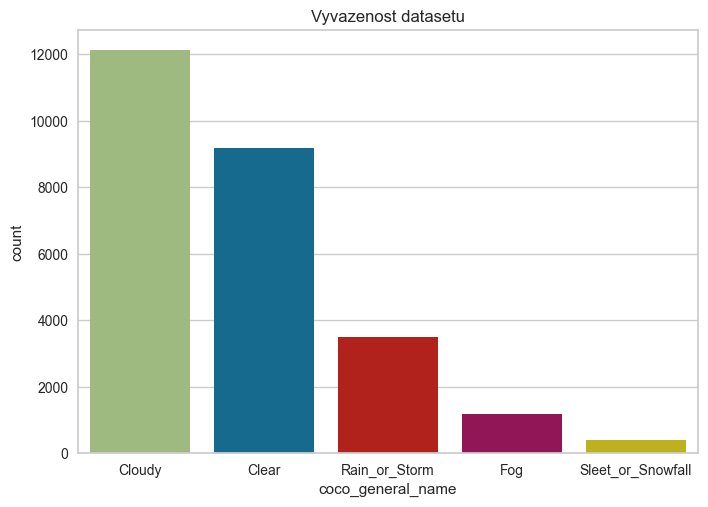

In [50]:
# vizualizacia pocetnosti pre kazdy kod pocasia
plt.title("Vyvazenost datasetu")
sb.countplot(data=df, x="coco_general_name", hue="coco_general_name",
             order=df["coco_general_name"].value_counts().index, legend=False)

## 4. Rozdelenie datasetu na train/test množinu `[0.5b]`

Rozdeľte celý dataset na trénovaciu/testovaciu množinu tak, aby v trénovacej množine bolo 80 % údajov a v testovacej 20 % údajov.

**Dôležité upozornenie:**
* Ak idete trénovať **regresné** modely: pri rozdeľovaní na train/test **nepoužívajte** stratifikáciu.
* Ak idete trénovať **klasifikačné** modely: pri rozdeľovaní na train/test **použite** stratifikáciu podľa stĺpca s kódom počasia.



Feature Engineering

In [51]:
# vytvorenie novych stlpcov pre hodinu a den roku v zazname
df["hour"] = df["time"].dt.hour
df["day_of_year"] = df["time"].dt.dayofyear
df

,time,temp,rhum,prcp,wdir,wspd,wpgt,pres,tsun,cldc,coco,coco_name,coco_general,coco_general_name,month,date,hour,day_of_year
0,2022-08-09 16:00:00,28.2,33,0.0,330,28.8,35.2,1020.5,47,2,2,Fair,0,Clear,8,2022-08-09,16,221
1,2022-08-09 17:00:00,26.9,34,0.0,340,28.8,31.5,1020.6,42,1,2,Fair,0,Clear,8,2022-08-09,17,221
2,2022-08-09 18:00:00,25.4,36,0.0,340,21.6,27.8,1021.3,28,1,1,Clear,0,Clear,8,2022-08-09,18,221
3,2022-08-09 19:00:00,23.6,38,0.0,340,14.4,25.9,1022.2,7,1,2,Fair,0,Clear,8,2022-08-09,19,221
4,2022-08-10 04:00:00,16.8,67,0.0,359,3.6,13.0,1024.0,3,5,3,Cloudy,1,Cloudy,8,2022-08-10,4,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26364,2025-12-31 19:00:00,0.0,75,0.2,270,28.0,31.5,1014.0,0,2,14,Light Snowfall,3,Sleet_or_Snowfall,12,2025-12-31,19,365
26365,2025-12-31 20:00:00,0.0,75,0.2,270,24.0,33.3,1014.0,0,8,14,Light Snowfall,3,Sleet_or_Snowfall,12,2025-12-31,20,365
26366,2025-12-31 21:00:00,0.6,73,0.0,270,32.0,35.2,1015.3,0,8,12,Sleet,3,Sleet_or_Snowfall,12,2025-12-31,21,365
26367,2025-12-31 22:00:00,1.0,69,0.2,270,19.0,37.0,1014.0,0,8,14,Light Snowfall,3,Sleet_or_Snowfall,12,2025-12-31,22,365


In [52]:
# stlpce pre priznaky
features = ["rhum", "prcp", "wdir", "wspd", "wpgt", "pres", "tsun", "cldc", "month", "hour", "day_of_year"]

# regresia - target je teplota, bez stratifikacie
x_reg = df[features]
y_reg = df["temp"]
train_x_reg, test_x_reg, train_y_reg, test_y_reg = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=None
)

# klasifikacia - target je zluceny kod pocasia, so stratifikaciou
# pri klasifikacii pridavame aj "temp" ako priznak
x_cls = df[features + ["temp"]]
y_cls = df["coco_general"]
train_x_cls, test_x_cls, train_y_cls, test_y_cls = train_test_split(
    x_cls, y_cls, test_size=0.2, random_state=None, stratify=y_cls
)

## 5. Normalizácia dát `[0.5b]`
Normalizujte všetky numerické stĺpce okrem cieľového príznaku (teplota v prípade regresie a kód počasia v prípade klasifikácie). Zvoľte takú normalizáciu, aby mali dáta v stĺpcoch priemer 0 a štandardnú odchýlku 1 (použite `StandardScaler`).

In [53]:
# regresia - normalizacia priznakov
scaler_reg = StandardScaler().set_output(transform="pandas")
train_x_reg_scaled = scaler_reg.fit_transform(train_x_reg)
test_x_reg_scaled = scaler_reg.transform(test_x_reg)

# klasifikacia - normalizacia priznakov
scaler_cls = StandardScaler().set_output(transform="pandas")
train_x_cls_scaled = scaler_cls.fit_transform(train_x_cls)
test_x_cls_scaled = scaler_cls.transform(test_x_cls)

## 6. Regresia `[8b]`

**Dôležité upozornenie 1:** Podmienkou udelenia bodov v tejto časti je, aby bol dataset správne rozdelený na train/test množinu, t.j. regresné modely sa nesmú trénovať a testovať na tej istej množine.

**Dôležité upozornenie 2:** Obidva modely (jednoduchá aj viacnásobná regresia) musia použiť tú istú trénovaciu aj testovaciu množinu.

### 6.1 Jednoduchá regresia `[4b]`

Teplotu budeme predpovedať **len pomocou 1 príznaku** (jednoduchá regresia).

**Postup:**
  1. Natrénujte model jednoduchej regresie na **trénovacej množine** tak, aby dosiahol na **testovacej množine** hodnotu metriky **R² (koeficient determinácie) aspoň 70 %**
      1. skúšajte rôzne typy modelov: lineárnu alebo polynomiálnu regresiu (vyberte taký typ, s ktorým viete dosiahnuť vyššie uvedenú hodnotu R²)
      2. vyberte 1 správny príznak (prediktor), pomocou ktorého budete predpovedať teplotu (alebo si vytvorte nový príznak v rámci feature engineering-u)
      3. určite vhodné parametre modelu (napr. stupeň polynómu)
  2. Vyhodnoťte tento model **na testovacej množine** (metriky R² a MAE)
  3. Zobrazte regresnú priamku (lineárna regresia) alebo krivku (polynomiálna regresia) **na testovacej množine**

**Nápoveda:** Dataset obsahuje vzácny stĺpec `time`, ktorý je dôležitým faktorom pri predpovedi počasia. Ak nie ste schopní dosiahnuť požadované R² pomocou existujúcich príznakov (`rhum`, `prcp` a pod.) tak si vytvorte nové stĺpce/prediktory, ktoré budú odvodené od stĺpca `time`. Napr. vytvorte stĺpce `month`(číslo mesiaca), `day_of_year`(poradové číslo dňa v roku) alebo `hour` (hodina v dni).

In [54]:
# vyber prediktora
predictor = "day_of_year"

# budeme trenovat len 1 priznak
train_x_simple = train_x_reg_scaled[[predictor]]
test_x_simple = test_x_reg_scaled[[predictor]]

# trenovanie viacnasobnej polynomionalej regresie na 1 priznaku
poly = PolynomialFeatures(degree=5)
train_x_poly = poly.fit_transform(train_x_simple)
test_x_poly = poly.transform(test_x_simple)

# trenovanie modelu
model = LinearRegression()
model.fit(train_x_poly, train_y_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
# predikcia na test sete
test_pred = model.predict(test_x_poly)

# metriky na test sete
r2 = r2_score(test_y_reg, test_pred)
rmse = np.sqrt(mean_squared_error(test_y_reg, test_pred))
mae = mean_absolute_error(test_y_reg, test_pred)

print(f"R2:   {r2:.4f} ({r2*100:.2f}%)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

R2:   0.7442 (74.42%)
RMSE: 4.4508
MAE:  3.5701


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


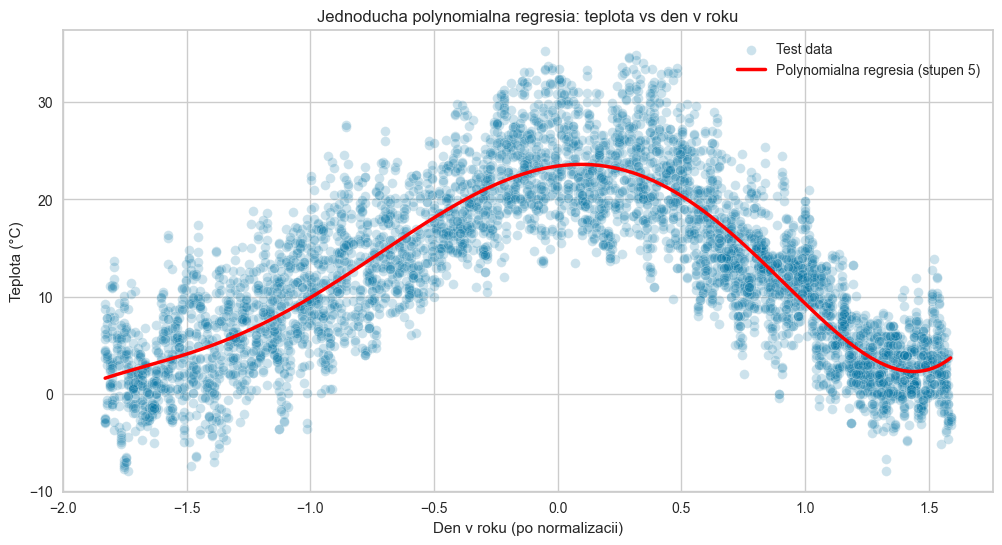

In [56]:
# vizualizacia
x_curve = np.linspace(train_x_simple.min().iloc[0], train_x_simple.max().iloc[0], 366).reshape(-1, 1)
x_curve_poly = poly.transform(x_curve)
y_curve = model.predict(x_curve_poly)

plt.figure(figsize=(12, 6))
sb.scatterplot(data=test_x_simple, x=predictor, y=test_y_reg, alpha=0.2, label="Test data")
plt.plot(x_curve, y_curve, color="red", linewidth=2.5, label="Polynomialna regresia (stupen 5)")
plt.title("Jednoducha polynomialna regresia: teplota vs den v roku")
plt.xlabel("Den v roku (po normalizacii)")
plt.ylabel("Teplota (°C)")
plt.legend()

### 6.2 Viacnásobná regresia `[4b]`

Teplotu budeme predpovedať **pomocou viacerých príznakov (2 a viac)** (viacnásobná regresia).

**Postup:**
  1. Natrénujte model viacnásobnej regresie na **trénovacej množine** tak, aby dosiahol na **testovacej množine** hodnotu metriky R² (koeficient determinácie) **aspoň 85 %**
      1. skúšajte rôzne typy modelov: lineárnu alebo polynomiálnu regresiu (vyberte taký typ, s ktorým viete dosiahnuť vyššie uvedenú hodnotu R²)
      2. vyberte správne príznaky (viaceré prediktory), pomocou ktorých budete predpovedať teplotu (alebo si vytvorte nové príznaky v rámci feature engineering-u)
      3. určite vhodné parametre modelu (napr. stupeň polynómu)
  2. Vyhodnoťte tento model **na testovacej množine** (metriky R² a MAE)
  3. Voliteľný krok: zobrazte regresnú rovinu/povrch len v prípade ak používate 2 prediktory (v prípade 3 a viac prediktorov vizualizácia nie je možná)

**Nápoveda:** Dataset obsahuje vzácny stĺpec `time`, ktorý je dôležitým faktorom pri predpovedi počasia. Ak nie ste schopní dosiahnuť požadované R² pomocou existujúcich príznakov (`rhum`, `prcp` a pod.) tak si vytvorte nové stĺpce/prediktory, ktoré budú odvodené od stĺpca `time`. Napr. vytvorte stĺpce `month`(číslo mesiaca), `day_of_year`(poradové číslo dňa v roku) alebo `hour` (hodina v dni).

In [57]:
# trenovanie viacnasobnej polynomionalej regresie na vsetkych 11 priznakoch
poly_multi = PolynomialFeatures(degree=3)
train_x_poly_multi = poly_multi.fit_transform(train_x_reg_scaled)
test_x_poly_multi = poly_multi.transform(test_x_reg_scaled)


# predikcia na test sete
model_multi = LinearRegression()
model_multi.fit(train_x_poly_multi, train_y_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
# predikcia na test sete
test_pred = model_multi.predict(test_x_poly_multi)

# metriky
r2 = r2_score(test_y_reg, test_pred)
rmse = np.sqrt(mean_squared_error(test_y_reg, test_pred))
mae = mean_absolute_error(test_y_reg, test_pred)

print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

R²:   0.8609 (86.09%)
RMSE: 3.2817
MAE:  2.5656


## 7. Klasifikácia `[8b]`

**Dôležité upozornenie 1:** Podmienkou udelenia bodov v tejto časti je, aby bol dataset správne rozdelený na train/test množinu, t.j. klasifikačné modely sa nesmú trénovať a testovať na tej istej množine.

**Dôležité upozornenie 2:** Obidva modely (single aj ensemble klasifikátor) musia použiť tú istú trénovaciu aj testovaciu množinu.

### 7.1 Single klasifikátor `[4b]`

Kód počasia budeme klasifikovať jedným z nasledovných typov klasifikátorov (určíte si ho sami):

* K-Nearest Neighbours
* Decision Tree
* Logistic Regression

**Postup:**
  1. Natrénujte single klasifikátor na **trénovacej množine** tak, aby dosiahol na **testovacej množine** hodnotu metriky **F1-Score (macro) aspoň 60 %**
      1. skúšajte modely K-Nearest Neighbours, Decision Tree alebo Logistic Regression (vyberte taký model, s ktorým viete dosiahnuť vyššie uvedené F1-score)
      2. vyberte správne príznaky (prediktory), pomocou ktorých budete klasifikovať kód počasia (alebo si vytvorte nové príznaky v rámci feature engineering-u)
      3. určite vhodné parametre modelu
  2. Vyhodnoťte najlepší model **na testovacej množine** (metriky Accuracy, Precision, Recall, F1-Score)
  3. Zobrazte ROC krivku a konfúznu maticu z výsledkov **na testovacej množine**

**Nápoveda 1:** Dataset obsahuje vzácny stĺpec `time`, ktorý je dôležitým faktorom pri klasifikácii počasia. Ak nie ste schopní dosiahnuť požadované F1-Score (macro) pomocou existujúcich príznakov (`rhum`, `prcp` a pod.) tak si vytvorte nové stĺpce/prediktory, ktoré budú odvodené od stĺpca `time`. Napr. vytvorte stĺpce `month`(číslo mesiaca), `day_of_year`(poradové číslo dňa v roku) alebo `hour` (hodina v dni).

**Nápoveda 2:** na hľadanie najlepších parametrov klasifikátora môžete použiť [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).


In [59]:
# GridSearchCV pre Decision Tree
param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 10, 20],
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(train_x_cls_scaled, train_y_cls)

print("Najlepsie parametre:", grid.best_params_)
print(f"Najlepsi F1-macro (CV): {grid.best_score_:.4f}")

Najlepsie parametre: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
Najlepsi F1-macro (CV): 0.6520


In [60]:
# natrenovanie modelu s najlepsimi najdenymi parametrami
tree = DecisionTreeClassifier(
    criterion=grid.best_params_["criterion"],
    max_depth=grid.best_params_["max_depth"],
    min_samples_split=grid.best_params_["min_samples_split"],
    class_weight=grid.best_params_["class_weight"],
    random_state=42
)
tree.fit(train_x_cls_scaled, train_y_cls)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [61]:
# predikcia na test sete
test_pred = tree.predict(test_x_cls_scaled)

# metriky
accuracy = accuracy_score(test_y_cls, test_pred)
precision = precision_score(test_y_cls, test_pred, average="macro", zero_division=0)
recall = recall_score(test_y_cls, test_pred, average="macro", zero_division=0)
f1 = f1_score(test_y_cls, test_pred, average="macro", zero_division=0)
conf = confusion_matrix(test_y_cls, test_pred)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-macro:  {f1:.4f} ({f1*100:.2f}%)")

Accuracy:  0.7374 (73.74%)
Precision: 0.6606 (66.06%)
Recall:    0.6552 (65.52%)
F1-macro:  0.6577 (65.77%)


Text(70.58159722222221, 0.5, 'Skutocnost')

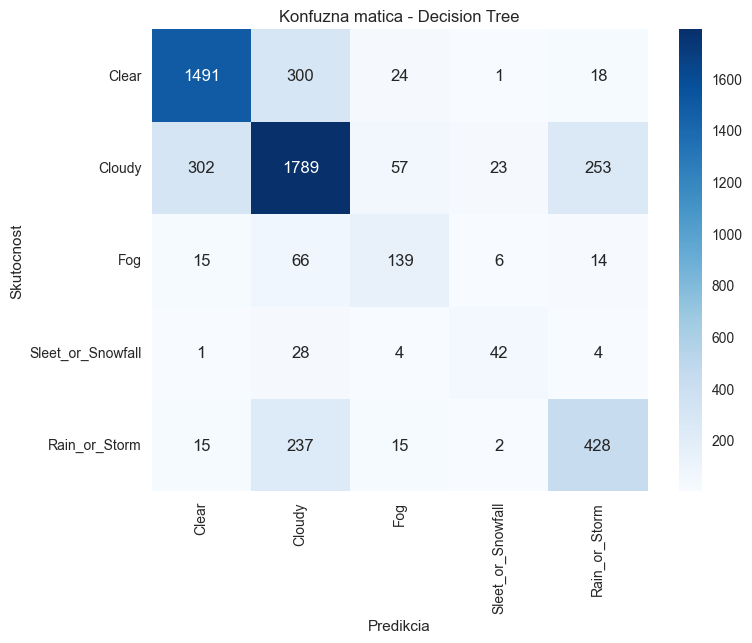

In [62]:
# konfuzna matica
class_names = ["Clear", "Cloudy", "Fog", "Sleet_or_Snowfall", "Rain_or_Storm"]

plt.figure(figsize=(8, 6))
sb.heatmap(conf, annot=True, fmt="d", cmap="Blues",
           xticklabels=class_names, yticklabels=class_names)
plt.title("Konfuzna matica - Decision Tree")
plt.xlabel("Predikcia")
plt.ylabel("Skutocnost")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(


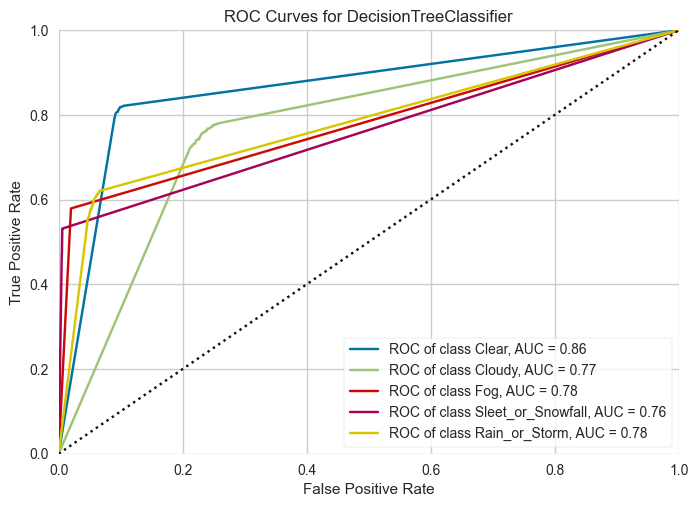

<Axes: title={'center': 'ROC Curves for DecisionTreeClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [63]:
# vizualizacia ROC kriviek
roc = ROCAUC(tree, classes=class_names, micro=False, macro=False, force_model=True)
roc.target_type_ = "multiclass"
roc.score(test_x_cls_scaled, test_y_cls)
for spine in roc.ax.spines.values():
    spine.set_visible(False)
roc.show()

### 7.2 Ensemble klasifikátor `[4b]`

Kód počasia budeme klasifikovať jedným z nasledovných typov klasifikátorov (určíte si ho sami):

* Random Forest
* XGBoost
* Basic Stacking

**Postup:**
  1. Natrénujte ensemble klasifikátor na **trénovacej množine** tak, aby dosiahol na **testovacej množine** hodnotu metriky **F1-Score (macro) aspoň 75 %**
      1. skúšajte modely Random Forest, XGBoost alebo Basic Stacking (vyberte taký model, s ktorým viete dosiahnuť vyššie uvedené F1-score)
      2. vyberte správne príznaky (prediktory), pomocou ktorých budete klasifikovať kód počasia (alebo si vytvorte nové príznaky v rámci feature engineering-u)
      3. určite vhodné parametre modelu
  2. Vyhodnoťte najlepší model **na testovacej množine** (metriky Accuracy, Precision, Recall, F1-Score)
  3. Zobrazte ROC krivku a konfúznu maticu z výsledkov **na testovacej množine**

**Nápoveda 1:** Dataset obsahuje vzácny stĺpec `time`, ktorý je dôležitým faktorom pri klasifikácii počasia. Ak nie ste schopní dosiahnuť požadované F1-Score (macro) pomocou existujúcich príznakov (`rhum`, `prcp` a pod.) tak si vytvorte nové stĺpce/prediktory, ktoré budú odvodené od stĺpca `time`. Napr. vytvorte stĺpce `month`(číslo mesiaca), `day_of_year`(poradové číslo dňa v roku) alebo `hour` (hodina v dni).

**Nápoveda 2:** na hľadanie najlepších parametrov klasifikátora môžete použiť [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

In [64]:
# Grid Search
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    xgboost.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(train_x_cls_scaled, train_y_cls)
print(f"Najlepsie nastavenie: {grid.best_params_}")
print(f"Najlepsi F1-macro (CV): {grid.best_score_:.4f}")

Najlepsie nastavenie: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400}
Najlepsi F1-macro (CV): 0.7677


In [65]:
# trenovanie XGBoost s najlepsimi parametrami
xgb = xgboost.XGBClassifier(
    n_estimators=grid.best_params_["n_estimators"],
    max_depth=grid.best_params_["max_depth"],
    learning_rate=grid.best_params_["learning_rate"],
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)
xgb.fit(train_x_cls_scaled, train_y_cls)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [66]:
# predikcia na test sete
test_pred = xgb.predict(test_x_cls_scaled)

# metriky
accuracy = accuracy_score(test_y_cls, test_pred)
precision = precision_score(test_y_cls, test_pred, average="macro", zero_division=0)
recall = recall_score(test_y_cls, test_pred, average="macro", zero_division=0)
f1 = f1_score(test_y_cls, test_pred, average="macro", zero_division=0)
conf = confusion_matrix(test_y_cls, test_pred)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-macro:  {f1:.4f} ({f1*100:.2f}%)")

Accuracy:  0.8402 (84.02%)
Precision: 0.7932 (79.32%)
Recall:    0.7364 (73.64%)
F1-macro:  0.7612 (76.12%)


Text(70.58159722222221, 0.5, 'Skutocnost')

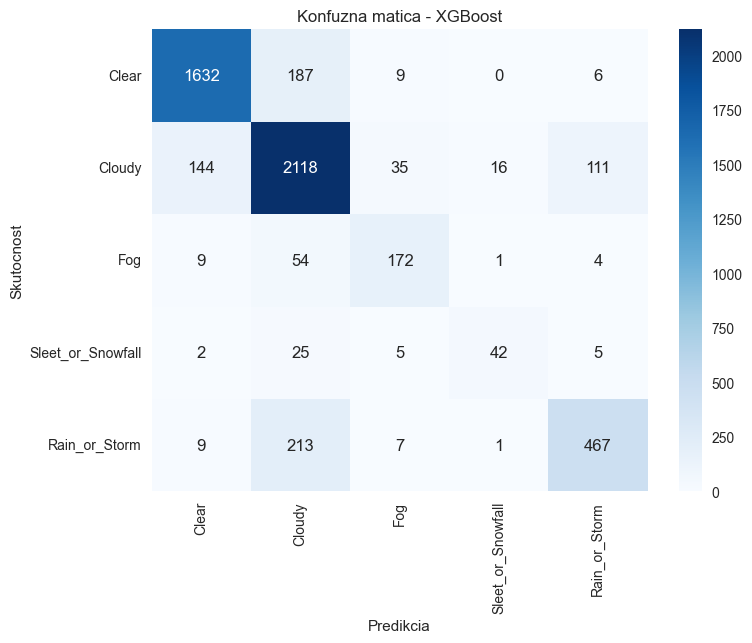

In [67]:
# matica konfuzie
plt.figure(figsize=(8, 6))
sb.heatmap(conf, annot=True, fmt="d", cmap="Blues",
           xticklabels=class_names, yticklabels=class_names)
plt.title("Konfuzna matica - XGBoost")
plt.xlabel("Predikcia")
plt.ylabel("Skutocnost")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(


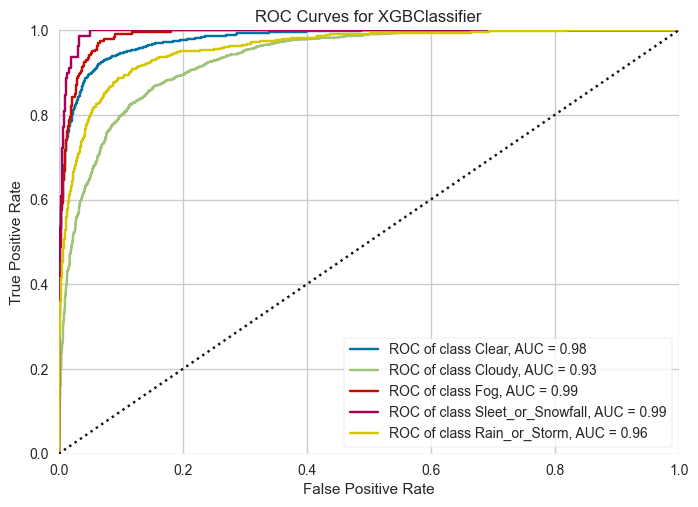

<Axes: title={'center': 'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [68]:
# ROC krivky
roc = ROCAUC(xgb, classes=class_names, micro=False, macro=False, force_model=True)
roc.target_type_ = "multiclass"
roc.score(test_x_cls_scaled, test_y_cls)
for spine in roc.ax.spines.values():
    spine.set_visible(False)
roc.show()